# 01 · Overview — CIFAR224, SimpleCIL + ViT-B/16 (pretrained)

Batch `b01_cifar224_simplecil_vitb16`: 7 scenarios x 3 seeds (21 runs), the
**real** pretrained ViT-B/16 backbone -- these are the scientifically
meaningful numbers in this repo (contrast with `b02_cifar100_matrix_full`,
which is framework validation on untrained stand-in backbones only).

Caveats that apply to every metric below (see `analysis/README.md`):
`FWT` is PILOT's zero-baseline approximation, not true FWT; `RAG_mean` only
scores each class's first revisit; `Long_Range_Retention` conflates label
aliasing with forgetting in the echo scenarios -- notebook 02 is entirely
about that last one.


In [1]:
import sys; sys.path.insert(0, '../..')
from core import loader, viz
viz.set_style()
BATCH = next(b for b in loader.discover_batches('../..') if b.name == 'b01_cifar224_simplecil_vitb16')
df = loader.load_per_task(BATCH)
print(BATCH.name, '|', len(df), 'per-task rows |',
      df[['method','scenario','seed']].drop_duplicates().shape[0], 'runs')

b01_cifar224_simplecil_vitb16 | 1512 per-task rows | 21 runs


In [2]:
SCENARIO_ORDER = [
    'disjoint_baseline', 'distribution_shift', 'cumulative_drift',
    'exact_replay', 'partial_overlap', 'mid_range_revisit', 'long_range_revisit',
]
SCENARIO_LABELS = {s: s.replace('_', ' ') for s in SCENARIO_ORDER}

### Final AIA and A_t per scenario (mean +/- SEM over 3 seeds)

In [3]:
aia = viz.final_task_per_seed(df, 'AIA', ['scenario'])
at = viz.final_task_per_seed(df, 'A_t', ['scenario'])
display(aia.set_index('scenario').reindex(SCENARIO_ORDER))

,mean,std,n,sem
scenario,,,,
disjoint_baseline,0.821679,0.001033,3,0.000596
distribution_shift,0.823314,0.000638,3,0.000368
cumulative_drift,0.841239,0.001200,3,0.000693
exact_replay,0.814571,0.000426,3,0.000246
partial_overlap,0.819221,0.004745,3,0.002740
mid_range_revisit,0.814886,0.001535,3,0.000886
long_range_revisit,0.815022,0.004272,3,0.002466


saved D:\Dev\Research\clover-cl\analysis\batches\b01_cifar224_simplecil_vitb16\figures\aia_by_scenario.png  +  .pdf


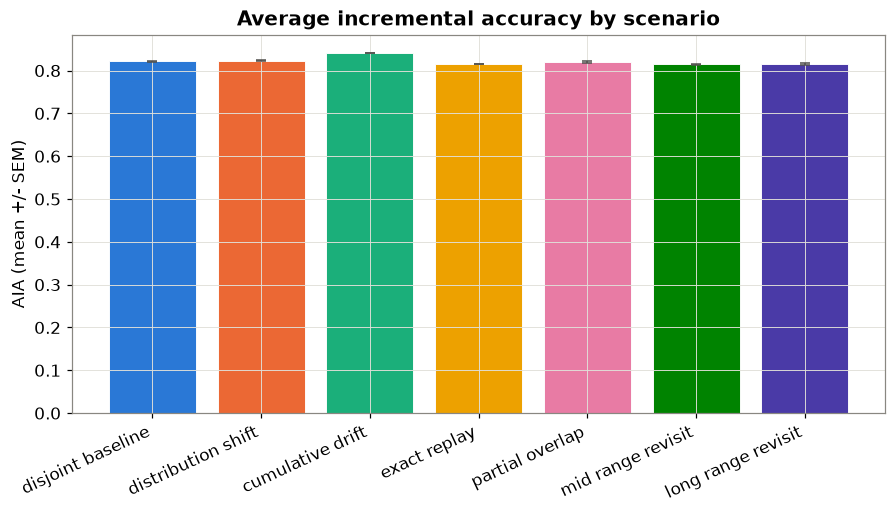

In [4]:
fig = viz.fig_bar_by_group(aia, 'scenario', SCENARIO_ORDER,
    'AIA (mean +/- SEM)', 'Average incremental accuracy by scenario', SCENARIO_LABELS)
viz.save_fig(fig, BATCH.path / 'figures', 'aia_by_scenario')

saved D:\Dev\Research\clover-cl\analysis\batches\b01_cifar224_simplecil_vitb16\figures\final_at_by_scenario.png  +  .pdf


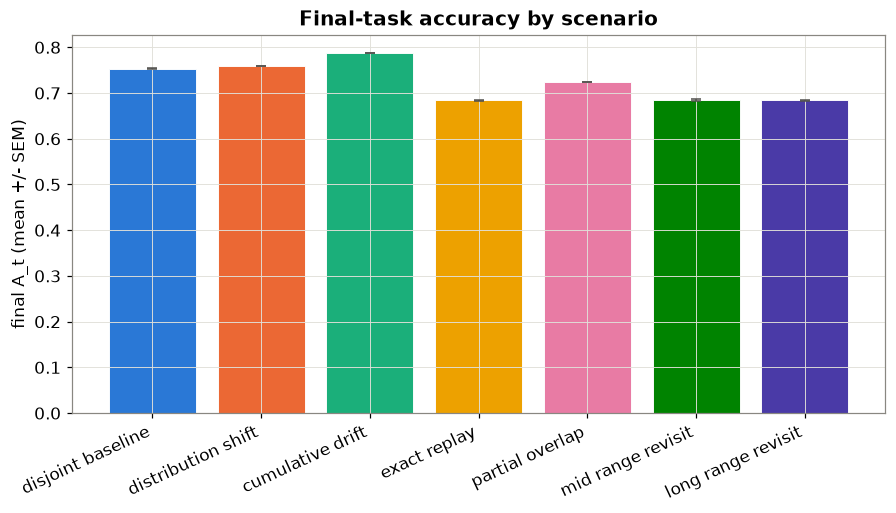

In [5]:
fig = viz.fig_bar_by_group(at, 'scenario', SCENARIO_ORDER,
    'final A_t (mean +/- SEM)', 'Final-task accuracy by scenario', SCENARIO_LABELS)
viz.save_fig(fig, BATCH.path / 'figures', 'final_at_by_scenario')

### Accuracy trajectory across the stream
`A_t` per task, mean +/- SEM band over the 3 seeds. Scenarios with an echo task (exact_replay, partial_overlap, mid_range/long_range_revisit) show the drop at their final task; see notebook 02 for why it isn't pure forgetting.

saved D:\Dev\Research\clover-cl\analysis\batches\b01_cifar224_simplecil_vitb16\figures\at_trajectory.png  +  .pdf


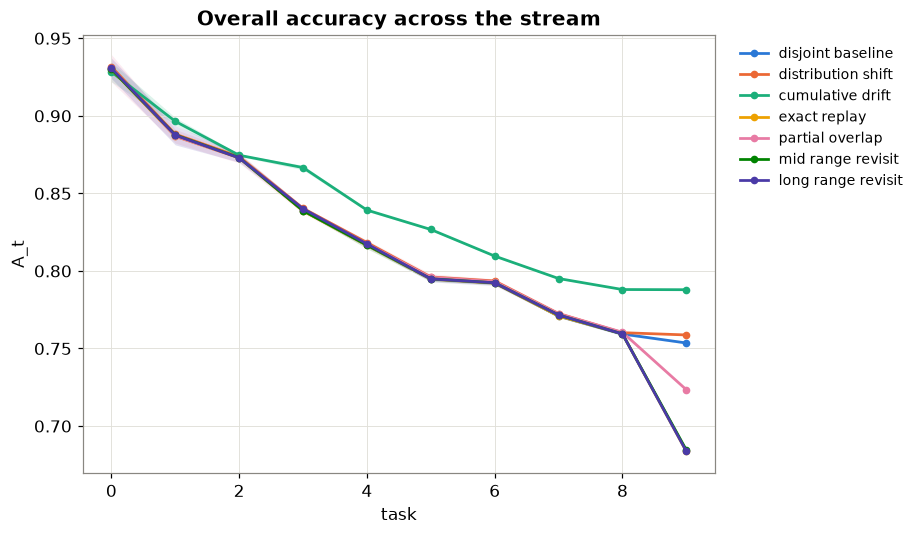

In [6]:
traj = viz.seed_mean_sem(df, 'A_t', ['scenario', 'task_idx'])
fig = viz.fig_trajectory_by_group(traj, 'scenario', SCENARIO_ORDER,
    'A_t', 'Overall accuracy across the stream', SCENARIO_LABELS)
viz.save_fig(fig, BATCH.path / 'figures', 'at_trajectory')

### Sanity check against the documented anchors
(`analysis/README.md` / the analysis task brief) -- if these don't match, the loader or metric code has a bug, not the data.

In [7]:
disjoint_aia = aia.set_index('scenario').loc['disjoint_baseline', 'mean']
print(f'disjoint_baseline AIA = {disjoint_aia:.3f} (anchor: 0.822)')
assert abs(disjoint_aia - 0.822) < 0.01, 'AIA anchor mismatch -- debug the loader/aggregation'
print('PASS')

disjoint_baseline AIA = 0.822 (anchor: 0.822)
PASS
